# 3 · Clusterização Temática (K-Means sobre o espaço latente)

Agrupa os 94 vereadores em clusters temáticos a partir do espaço **latente de 64d**
(autoencoder). O `cluster_id` é uma feature **explicativa e desacoplada** — o ranking de
recomendação roda nos 768d e **não** depende do cluster.

> ⚠️ **n = 94 é pequeno.** Os clusters são exploratórios; espere silhouette baixa.

In [1]:
import sys; sys.path.insert(0, '..')  # importa os módulos de recommendation/src
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import clustering

latente, meta = clustering.carregar_latente()
print('latente:', latente.shape, '| vereadores:', len(meta))

[clustering] Latente: (94, 64)  | Metadados: 94 vereadores
latente: (94, 64) | vereadores: 94


## Escolha de k — elbow (inércia) + silhouette

In [2]:
diagnostico = clustering.avaliar_k(latente)
diagnostico

  k= 2  inertia=    68.113  silhouette= 0.156  menor_cluster=47
  k= 3  inertia=    62.657  silhouette= 0.139  menor_cluster=14
  k= 4  inertia=    57.855  silhouette= 0.145  menor_cluster=16
  k= 5  inertia=    55.101  silhouette= 0.125  menor_cluster=11
  k= 6  inertia=    53.012  silhouette= 0.109  menor_cluster=8
  k= 7  inertia=    51.445  silhouette= 0.104  menor_cluster=5
  k= 8  inertia=    49.963  silhouette= 0.105  menor_cluster=2


,k,inertia,silhouette,menor_cluster
0,2,68.113495,0.156285,47
1,3,62.657448,0.138936,14
2,4,57.854828,0.144995,16
3,5,55.101120,0.124926,11
4,6,53.011528,0.108509,8
5,7,51.444740,0.103744,5
6,8,49.963253,0.105344,2


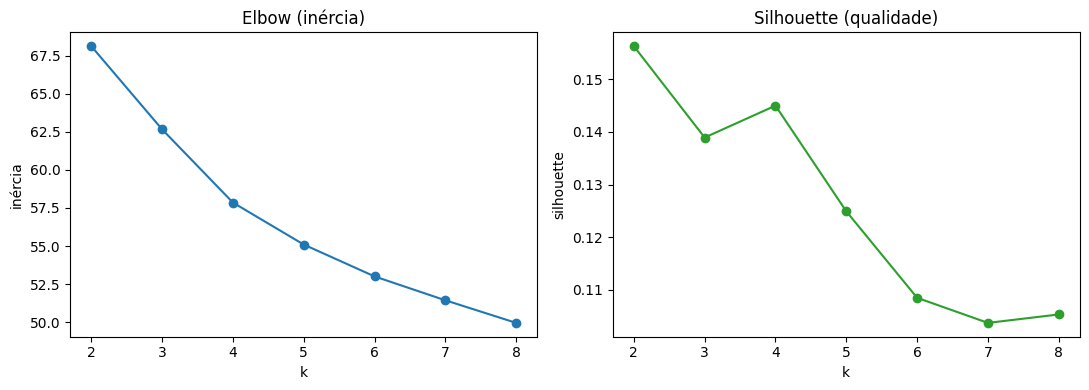

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(diagnostico['k'], diagnostico['inertia'], 'o-'); ax1.set_title('Elbow (inércia)')
ax1.set_xlabel('k'); ax1.set_ylabel('inércia')
ax2.plot(diagnostico['k'], diagnostico['silhouette'], 'o-', color='tab:green')
ax2.set_title('Silhouette (qualidade)'); ax2.set_xlabel('k'); ax2.set_ylabel('silhouette')
plt.tight_layout(); plt.show()

In [4]:
k = clustering.escolher_k(diagnostico)
labels, modelo = clustering.clusterizar(latente, k)
print('tamanhos dos clusters:', np.bincount(labels).tolist())

[clustering] k escolhido = 2  (silhouette=0.156, sem clusters pequenos)
[clustering] Clusters (k=2) — tamanhos: [47, 47]
tamanhos dos clusters: [47, 47]


## Projeção 2D (PCA) colorida por cluster

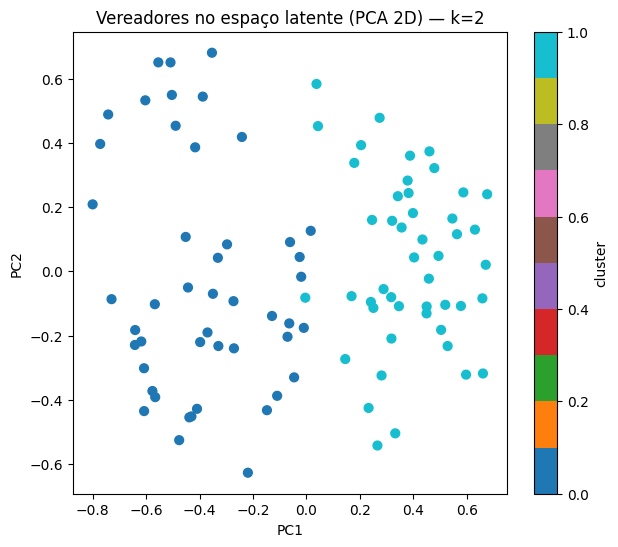

In [5]:
coords = PCA(n_components=2, random_state=42).fit_transform(latente)
plt.figure(figsize=(7, 6))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='tab10', s=40)
plt.title(f'Vereadores no espaço latente (PCA 2D) — k={k}')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.colorbar(sc, label='cluster'); plt.show()

## Interpretação temática — ementas mais frequentes por cluster

In [6]:
# caminho absoluto via constante do módulo (independe do CWD); 'vereador' -> 'nome'
df = pd.read_csv(clustering.BASE_DIR / 'data' / 'df_nlp_filtrado.csv').rename(columns={'vereador': 'nome'})
meta_cl = meta.copy(); meta_cl['cluster_id'] = labels
df_cl = df.merge(meta_cl, on=['nome', 'municipio'], how='inner')
for c in sorted(meta_cl['cluster_id'].unique()):
    sub = df_cl[df_cl['cluster_id'] == c]['proposta_ementa_filtrada'].dropna()
    sub = sub[sub != 'sem_proposta_ementa']
    print(f'\n=== cluster {c}  ({(meta_cl.cluster_id==c).sum()} vereadores, {len(sub)} ementas) ===')
    for t in sub.value_counts().head(5).index:
        print('  •', t[:90])


=== cluster 0  (47 vereadores, 916 ementas) ===
  • diretrizes orçamantaria 2026
  • impositiva modificativa aditiva substitutiva supressiva 174 2025 orçamentário anual exercí
  • diretrizes orçamantária 2026
  • estima receita fixa despesa para exercício financeiro 2026 outras providências
  • dispõe denominação rua adota outras providências

=== cluster 1  (47 vereadores, 1093 ementas) ===
  • diretrizes orçamantaria 2026
  • impositiva modificativa aditiva substitutiva supressiva 174 2025 orçamentário anual exercí
  • dispõe denominação rua adota outras providências
  • modifica redação caput 110
  • modifica redação inciso 110 2025


## Leitura honesta (n=94)

A silhouette fica baixa (~0.1–0.16), o que é **esperado** para 94 pontos: as pautas
legislativas municipais se sobrepõem muito (saúde, obras, homenagens). Por isso o
`cluster_id` é tratado como **rótulo descritivo**, nunca como filtro do ranking — que
roda na similaridade de cosseno em 768d, robusta independente da qualidade do cluster.